# EPL Match Data — Exploration

Purpose: build the evidence base for Feature Engineering decisions — what to keep, discard, or collapse.

Scope for this pass: every non-betting column gets looked at individually. Betting/odds columns (many sparsely populated across the 15+ season history) are analysed together in one combined section at the end, rather than one bookmaker at a time.

Notable findings get written up separately in `docs/EDA_FINDINGS.md` — this notebook is for the analysis itself.

In [36]:
import sys
from pathlib import Path

# Notebooks run with their own folder as the working directory, so src/
# (a sibling of notebooks/, not inside it) isn't importable by default -
# add the project root to Python's search path before importing from src.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import DATA_INTERIM_PATH

sns.set_theme(style="whitegrid")

In [38]:
df = pd.read_csv(DATA_INTERIM_PATH / "matches.csv", parse_dates=["Date"])
df.shape

(6080, 193)

## 1. Target Distributions

What we're checking: how imbalanced is the classification target (`FTR`), and what does the goal-difference distribution (the regression target) look like?

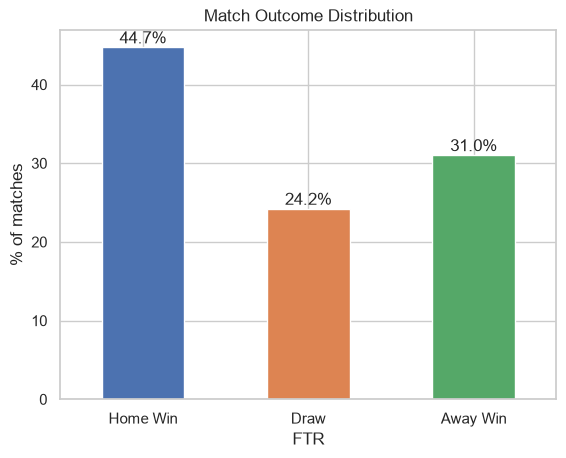

FTR
H    44.736842
D    24.226974
A    31.036184
Name: proportion, dtype: float64

In [39]:
result_counts = df["FTR"].value_counts(normalize=True) * 100
result_counts = result_counts.reindex(["H", "D", "A"])

ax = result_counts.plot(kind="bar", color=["#4C72B0", "#DD8452", "#55A868"])
ax.set_xticklabels(["Home Win", "Draw", "Away Win"], rotation=0)
ax.set_ylabel("% of matches")
ax.set_title("Match Outcome Distribution")
for i, v in enumerate(result_counts):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha="center")
plt.show()

result_counts

In [ ]:
df["GoalDifference"] = df["FTHG"] - df["FTAG"]

# Raw counts printed here for direct cross-checking against the chart below.
df["GoalDifference"].value_counts().sort_index()

In [ ]:
# Standalone figure, own cell, so it's unambiguous. Bins centered on each
# integer (edges at n-0.5) so each bar sits directly under its own label,
# spanning the full observed range so no extreme values get dropped, and
# an explicit tick at every integer so no bar is left unlabeled.
lo, hi = int(df["GoalDifference"].min()), int(df["GoalDifference"].max())
bins = [x - 0.5 for x in range(lo, hi + 2)]

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(df["GoalDifference"], bins=bins, edgecolor="black")
ax.set_xticks(range(lo, hi + 1))
ax.set_xlabel("Goal Difference (Home - Away)")
ax.set_title("Goal Difference Distribution")
plt.show()

In [ ]:
print(f"Skewness: {df['GoalDifference'].skew():.3f}")  # 0 = symmetric
print(f"Kurtosis: {df['GoalDifference'].kurt():.3f}")  # 0 = normal-like tail weight (excess kurtosis)

df["GoalDifference"].describe()

## 2. Home Advantage Over Time

What we're checking: has the home/draw/away split stayed stable across all seasons, or has it drifted? This is the check of the "concept drift" concern raised in `docs/PROJECT_OVERVIEW.md` related to the inclusion of older seasons.

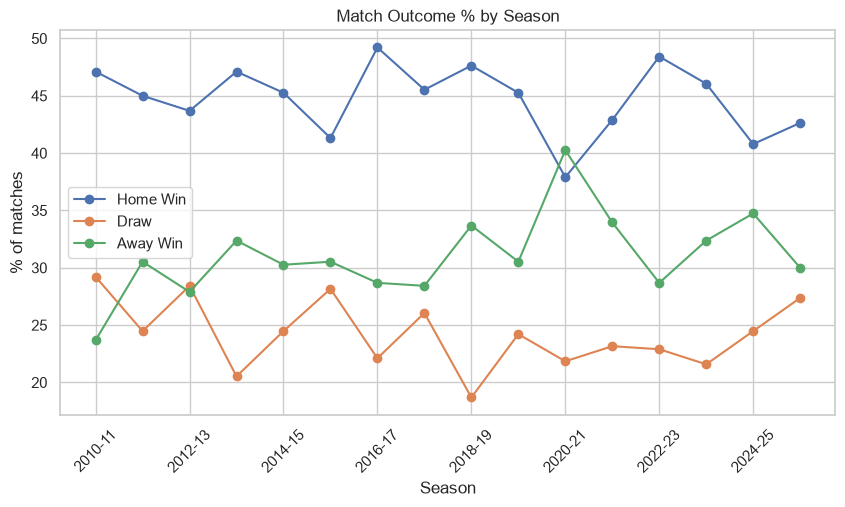

FTR,H,D,A
Season,,,
2010-11,47.105263,29.210526,23.684211
2011-12,45.000000,24.473684,30.526316
2012-13,43.684211,28.421053,27.894737
2013-14,47.105263,20.526316,32.368421
2014-15,45.263158,24.473684,30.263158
2015-16,41.315789,28.157895,30.526316
2016-17,49.210526,22.105263,28.684211
2017-18,45.526316,26.052632,28.421053
2018-19,47.631579,18.684211,33.684211


In [41]:
by_season = (
    df.groupby("Season")["FTR"]
    .value_counts(normalize=True)
    .unstack()
    .reindex(columns=["H", "D", "A"])
    * 100
)

ax = by_season.plot(kind="line", marker="o", figsize=(10, 5))
ax.set_ylabel("% of matches")
ax.set_title("Match Outcome % by Season")
ax.legend(["Home Win", "Draw", "Away Win"])
plt.xticks(rotation=45)
plt.show()

by_season

In [ ]:
# Goal-scoring trend over time - separate from the win/draw/loss split above.
# Note: any drift here is confounded with manager/tactical changes at
# individual clubs, not just league-wide era effects - can't disentangle
# the two from season-level aggregates alone.
goals_by_season = df.groupby("Season")[["FTHG", "FTAG"]].mean()
goals_by_season["TotalGoals"] = goals_by_season["FTHG"] + goals_by_season["FTAG"]

ax = goals_by_season.plot(kind="line", marker="o", figsize=(10, 5))
ax.set_ylabel("Average goals per match")
ax.set_title("Average Goals Scored per Match by Season")
plt.xticks(rotation=45)
plt.show()

goals_by_season

## 3. Match Statistics (non-betting columns)

First, split columns into "match info/stats" (per `docs/DATA_DICTIONARY.md`) vs. everything else (treated as betting/odds, analysed later as a batch).

In [ ]:
MATCH_COLUMNS = [
    "Div", "Date", "Time", "HomeTeam", "AwayTeam",
    "FTHG", "FTAG", "FTR", "HTHG", "HTAG", "HTR", "Referee",
    "HS", "AS", "HST", "AST", "HHW", "AHW", "HC", "AC",
    "HF", "AF", "HFKC", "AFKC", "HO", "AO",
    "HY", "AY", "HR", "AR", "HBP", "ABP",
    "Season", "GoalDifference",
]
match_columns_present = [c for c in MATCH_COLUMNS if c in df.columns]
betting_columns = [c for c in df.columns if c not in MATCH_COLUMNS]

print(f"{len(match_columns_present)} match/info/stat columns, {len(betting_columns)} betting/odds columns")
match_columns_present

In [43]:
match_numeric_columns = df[match_columns_present].select_dtypes("number").columns.tolist()
df[match_numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
FTHG,6080.0,1.553947,1.307369,0.0,1.0,1.0,2.0,9.0
FTAG,6080.0,1.245066,1.186843,0.0,0.0,1.0,2.0,9.0
HTHG,6080.0,0.697368,0.845058,0.0,0.0,0.0,1.0,5.0
HTAG,6080.0,0.549671,0.761921,0.0,0.0,0.0,1.0,5.0
HS,6080.0,14.065625,5.570391,0.0,10.0,14.0,17.0,43.0
AS,6080.0,11.430757,4.902887,0.0,8.0,11.0,14.0,37.0
HST,6080.0,5.367599,3.089268,0.0,3.0,5.0,7.0,24.0
AST,6080.0,4.399836,2.655123,0.0,2.0,4.0,6.0,20.0
HC,6080.0,5.849178,3.115443,0.0,4.0,5.0,8.0,19.0
AC,6080.0,4.738158,2.773430,0.0,3.0,4.0,6.0,19.0


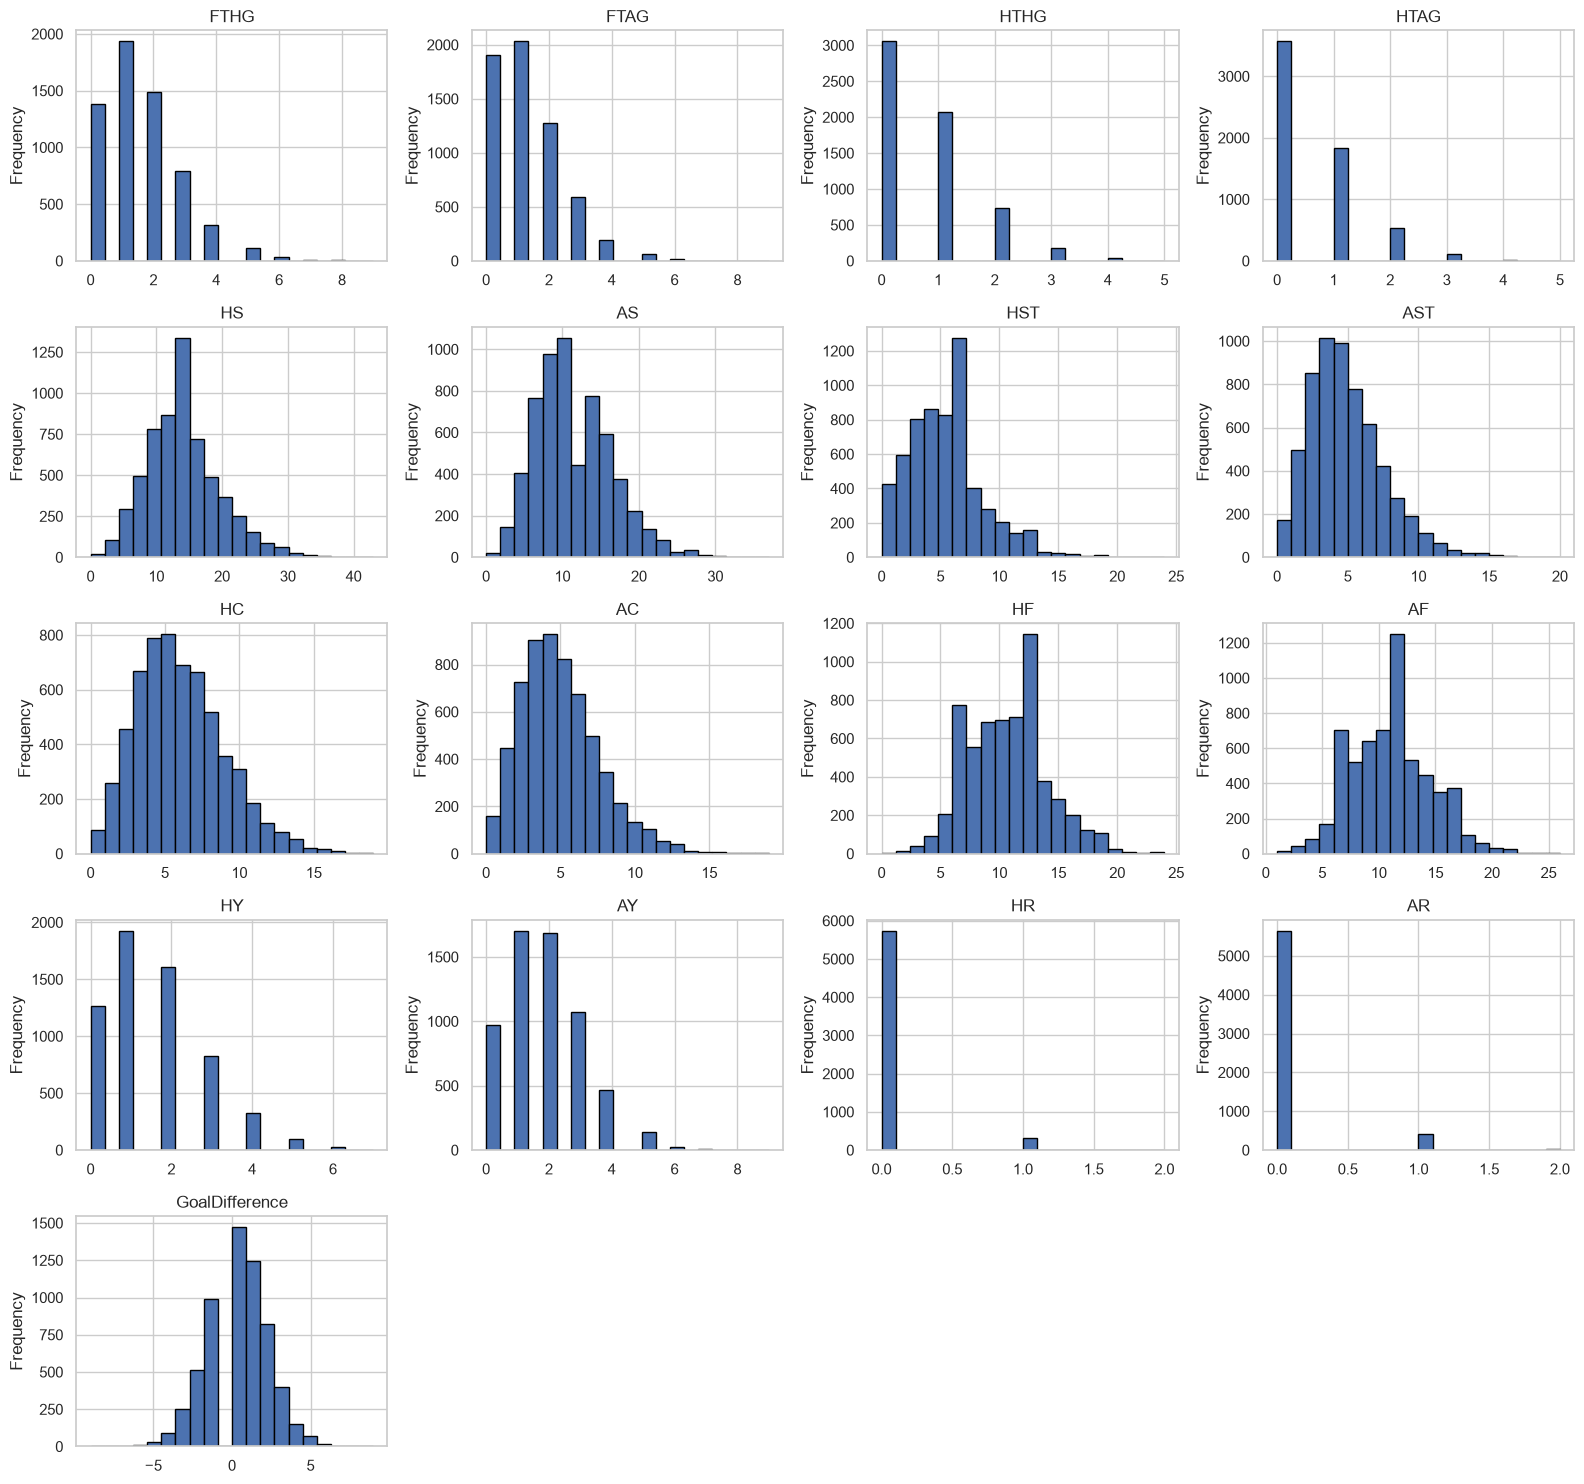

In [44]:
n_cols = 4
n_rows = -(-len(match_numeric_columns) // n_cols)  # ceiling division
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, match_numeric_columns):
    df[col].plot(kind="hist", bins=20, ax=ax, edgecolor="black")
    ax.set_title(col)

for ax in axes[len(match_numeric_columns):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

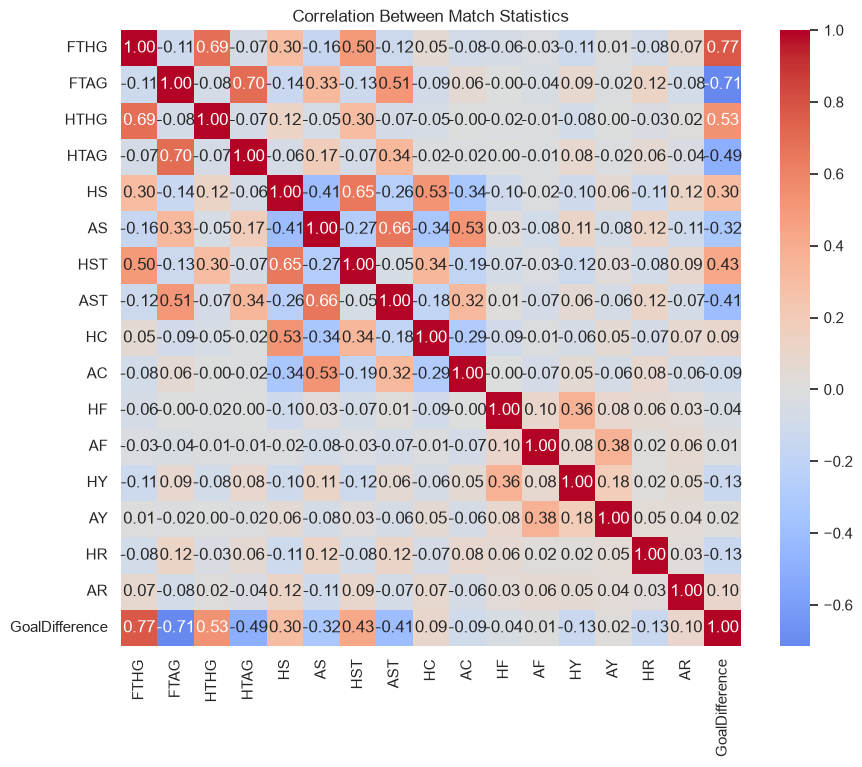

In [45]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df[match_numeric_columns].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Between Match Statistics")
plt.show()

## 4. Missingness (non-betting columns)

What we're checking: which match-info/stat columns have missing data, and is it concentrated in specific seasons (e.g. older seasons lacking certain stats)?

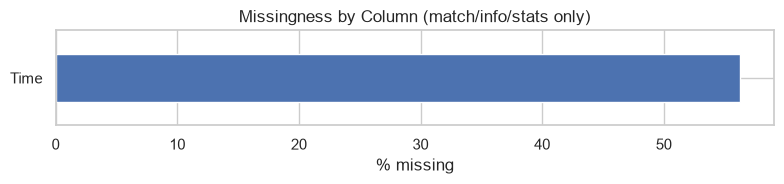

Time    56.25
dtype: float64

In [46]:
missing_pct = df[match_columns_present].isna().mean().sort_values(ascending=False) * 100
missing_pct = missing_pct[missing_pct > 0]

if missing_pct.empty:
    print("No missing values in any match/info/stat column.")
else:
    ax = missing_pct.plot(kind="barh", figsize=(8, max(2, 0.3 * len(missing_pct))))
    ax.set_xlabel("% missing")
    ax.set_title("Missingness by Column (match/info/stats only)")
    plt.tight_layout()
    plt.show()

missing_pct

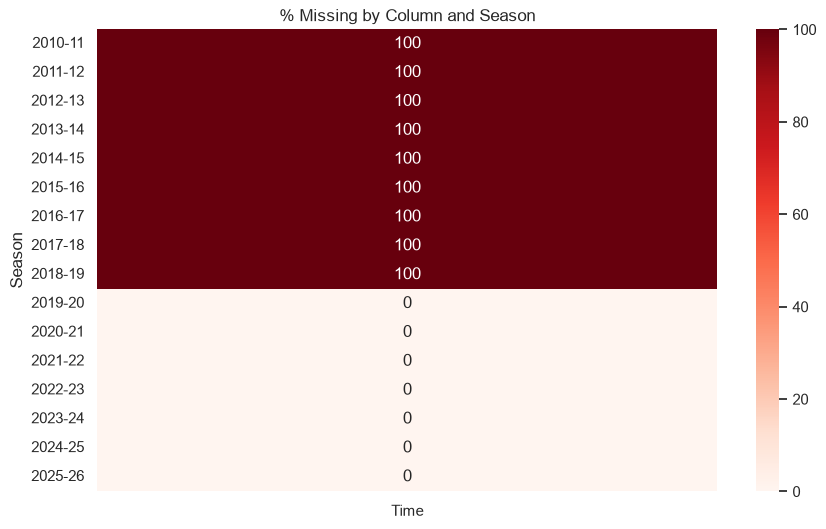

In [47]:
if not missing_pct.empty:
    missing_by_season = (
        df.groupby("Season")[missing_pct.index.tolist()]
        .apply(lambda g: g.isna().mean() * 100)
    )
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.heatmap(missing_by_season, annot=True, fmt=".0f", cmap="Reds", ax=ax)
    ax.set_title("% Missing by Column and Season")
    plt.show()

## 5. Betting/Odds Columns (combined analysis)

Rather than one bookmaker at a time: (a) how populated is each odds column overall, (b) how closely do the main providers agree with each other (redundancy check), and (c) do the odds actually predict outcomes (calibration sanity check)?

9 of 168 betting columns have >=90% coverage
39 of 168 betting columns have <10% coverage


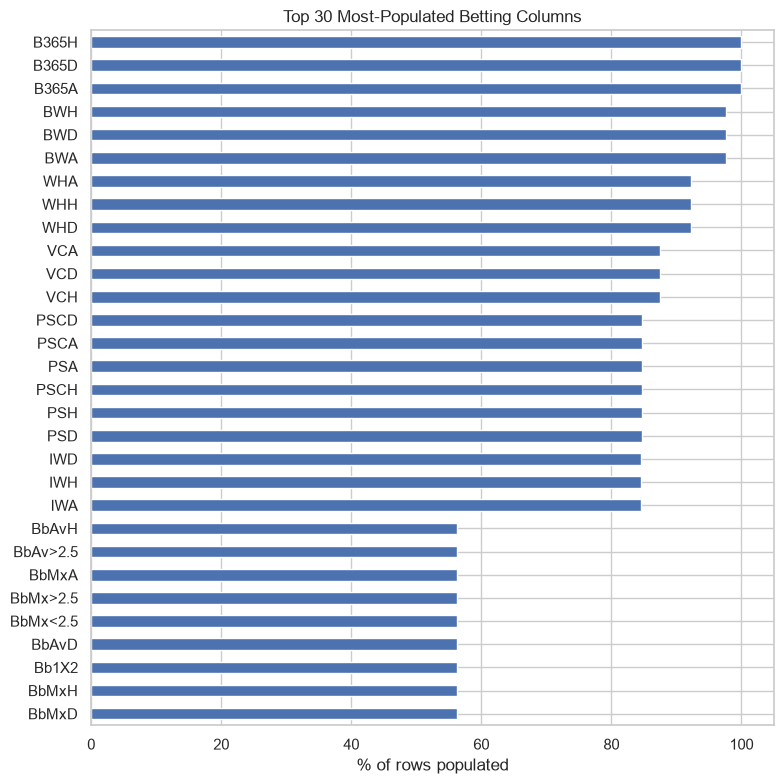

In [48]:
coverage = (df[betting_columns].notna().mean() * 100).sort_values(ascending=False)

print(f"{(coverage >= 90).sum()} of {len(coverage)} betting columns have >=90% coverage")
print(f"{(coverage < 10).sum()} of {len(coverage)} betting columns have <10% coverage")

ax = coverage.head(30).plot(kind="barh", figsize=(8, 8))
ax.invert_yaxis()
ax.set_xlabel("% of rows populated")
ax.set_title("Top 30 Most-Populated Betting Columns")
plt.tight_layout()
plt.show()

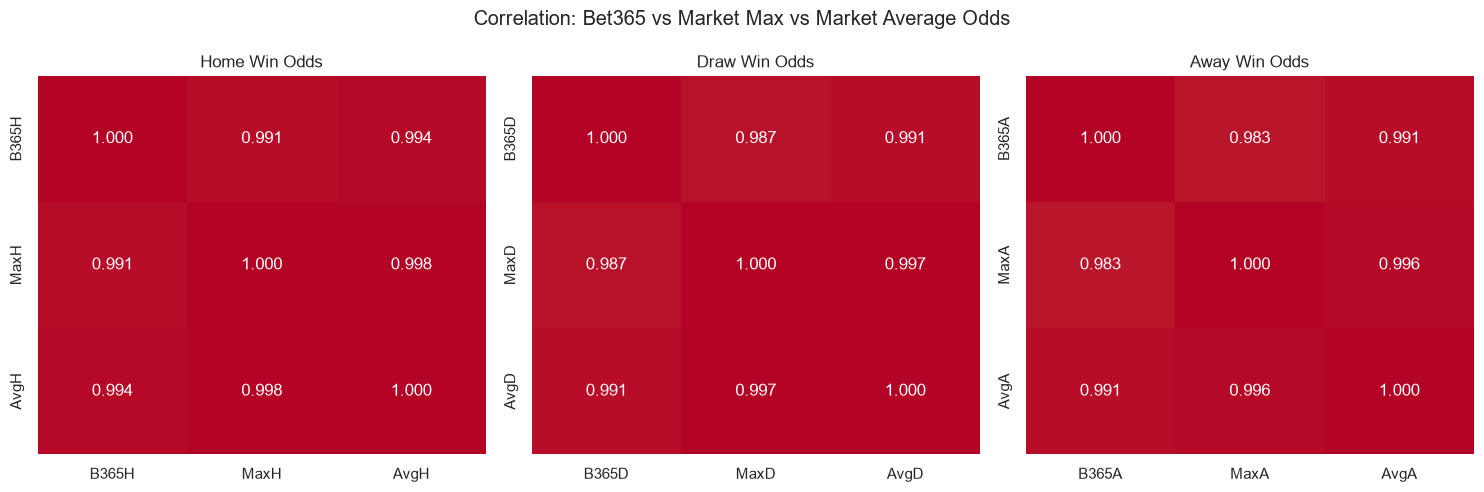

In [49]:
outcome_groups = {"Home": "H", "Draw": "D", "Away": "A"}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (label, suffix) in zip(axes, outcome_groups.items()):
    cols = [c for c in [f"B365{suffix}", f"Max{suffix}", f"Avg{suffix}"] if c in df.columns]
    sns.heatmap(df[cols].corr(), annot=True, fmt=".3f", cmap="coolwarm", vmin=0, vmax=1, ax=ax, cbar=False)
    ax.set_title(f"{label} Win Odds")

plt.suptitle("Correlation: Bet365 vs Market Max vs Market Average Odds")
plt.tight_layout()
plt.show()

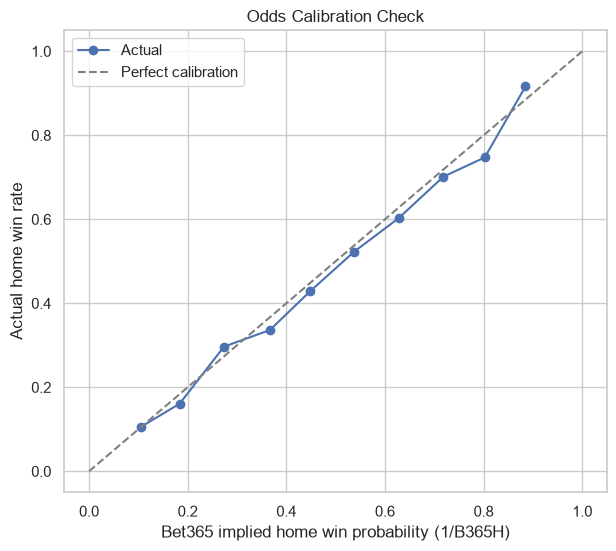

,mean_implied_prob,actual_home_win_rate,n_matches
ProbBucket,,,
"(0.0426, 0.133]",0.105944,0.106299,254
"(0.133, 0.223]",0.183564,0.160772,622
"(0.223, 0.313]",0.273755,0.296736,674
"(0.313, 0.403]",0.366554,0.336273,907
"(0.403, 0.493]",0.448116,0.428305,1074
"(0.493, 0.583]",0.536739,0.521991,864
"(0.583, 0.673]",0.627772,0.602694,594
"(0.673, 0.763]",0.718525,0.701431,489
"(0.763, 0.853]",0.802288,0.747204,447


In [50]:
calib = df.dropna(subset=["B365H"]).copy()
calib["ImpliedHomeProb"] = 1 / calib["B365H"]
calib["ProbBucket"] = pd.cut(calib["ImpliedHomeProb"], bins=10)

bucket_stats = calib.groupby("ProbBucket", observed=True).agg(
    mean_implied_prob=("ImpliedHomeProb", "mean"),
    actual_home_win_rate=("FTR", lambda s: (s == "H").mean()),
    n_matches=("FTR", "count"),
)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(bucket_stats["mean_implied_prob"], bucket_stats["actual_home_win_rate"], marker="o", label="Actual")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
ax.set_xlabel("Bet365 implied home win probability (1/B365H)")
ax.set_ylabel("Actual home win rate")
ax.set_title("Odds Calibration Check")
ax.legend()
plt.show()

bucket_stats

## 6. Team-Specific Home/Away Stats

What we're checking: league-wide home advantage is one thing, but does every team benefit from it equally? A team-by-team breakdown of home vs. away win rate and goals.

In [ ]:
home_stats = df.groupby("HomeTeam").agg(
    home_matches=("FTR", "count"),
    home_win_pct=("FTR", lambda s: (s == "H").mean() * 100),
    home_goals_scored=("FTHG", "mean"),
    home_goals_conceded=("FTAG", "mean"),
)

away_stats = df.groupby("AwayTeam").agg(
    away_matches=("FTR", "count"),
    away_win_pct=("FTR", lambda s: (s == "A").mean() * 100),
    away_goals_scored=("FTAG", "mean"),
    away_goals_conceded=("FTHG", "mean"),
)

team_stats = home_stats.join(away_stats, how="outer")
team_stats["home_away_win_pct_gap"] = team_stats["home_win_pct"] - team_stats["away_win_pct"]
team_stats.sort_values("home_away_win_pct_gap", ascending=False)

In [ ]:
plot_data = team_stats.sort_values("home_away_win_pct_gap", ascending=False)[["home_win_pct", "away_win_pct"]]

ax = plot_data.plot(kind="barh", figsize=(8, 12))
ax.invert_yaxis()
ax.set_xlabel("Win %")
ax.set_title("Home vs Away Win % by Team (sorted by home advantage gap)")
plt.tight_layout()
plt.show()

## 7. Head-to-Head Matchup Feasibility

Not building the actual head-to-head feature here (that's Feature Engineering) - just checking whether the data supports it: do team pairings actually repeat often enough across the 16 seasons to compute a meaningful "last 5-10 meetings" record?

In [ ]:
# Unordered pairing (Man United vs Arsenal counted the same regardless of
# who's home) - this is the "overall matchup" count. A same-stadium-only
# count would instead group by (HomeTeam, AwayTeam) without sorting.
pairs = df.apply(lambda r: tuple(sorted([r["HomeTeam"], r["AwayTeam"]])), axis=1)
matchup_counts = pairs.value_counts()

print(f"{len(matchup_counts)} distinct team pairings across the dataset")
print(matchup_counts.describe())

matchup_counts.head(10)

In [ ]:
# Illustrative example: a well-known rivalry, to see what an actual
# head-to-head record looks like in this data.
h2h = df[
    ((df["HomeTeam"] == "Man United") & (df["AwayTeam"] == "Arsenal"))
    | ((df["HomeTeam"] == "Arsenal") & (df["AwayTeam"] == "Man United"))
].sort_values("Date")

print(f"{len(h2h)} meetings between Man United and Arsenal in this dataset")
h2h[["Date", "Season", "HomeTeam", "AwayTeam", "FTHG", "FTAG", "FTR"]].tail(10)